# 09 · Parallel nodes are not threads

## Learning objectives

- Compare success-on-all and success-on-one policies.
- Explain failure and synchronization.
- Separate traversal from concurrency.

**Environment:** the standalone Python kernel from the README. No ROS installation or sourcing is needed. Run all cells from top to bottom; each notebook starts with its own state.

## Intuition

A py_trees **Parallel** ticks its children during the same traversal. It does not create
threads. Each child's update must still return promptly. With SuccessOnAll, all children
must succeed; with SuccessOnOne, at least one must succeed. In both policies, **any child
failure makes the parallel fail**, even if another succeeds. Synchronization can skip children
that already succeeded while waiting for the others.

In [2]:
import py_trees as pt
from behavior_trees_tutorial.behaviors.common import Function, CountTicks, Status
from behavior_trees_tutorial.visualization import diagram, trace, playground
from IPython.display import display

## Minimal working example

1 Prepare together: RUNNING | Camera ready: SUCCESS | Arm ready: RUNNING
2 Prepare together: RUNNING | Camera ready: SUCCESS | Arm ready: RUNNING
3 Prepare together: SUCCESS | Camera ready: SUCCESS | Arm ready: SUCCESS


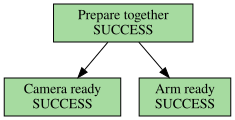

In [3]:
root = pt.composites.Parallel("Prepare together",
    policy=pt.common.ParallelPolicy.SuccessOnAll(synchronise=True), children=[
        CountTicks("Camera ready", ticks=1), CountTicks("Arm ready", ticks=3)])
trace(root, 3)
assert root.status is Status.SUCCESS
display(diagram(root))

## Step-by-step implementation
Both children receive tick 1. Camera succeeds immediately and is skipped while Arm
continues. SuccessOnOne is useful for alternative completion signals, but it is not a
“first success wins regardless of failure” race. On completion, running siblings are stopped.

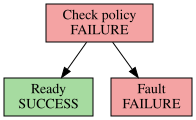

In [4]:
failure_wins = pt.composites.Parallel("Check policy",
    policy=pt.common.ParallelPolicy.SuccessOnOne(), children=[
        pt.behaviours.Success("Ready"), pt.behaviours.Failure("Fault")])
failure_wins.tick_once()
assert failure_wins.status is Status.FAILURE
display(diagram(failure_wins))

## Interactive demonstration

In [5]:
import ipywidgets as widgets

@widgets.interact(all_required=True, synchronise=True)
def policies(all_required=True, synchronise=True):
    policy = (pt.common.ParallelPolicy.SuccessOnAll(synchronise=synchronise)
              if all_required else pt.common.ParallelPolicy.SuccessOnOne())
    tree = pt.composites.Parallel("Prepare", policy=policy, children=[
        CountTicks("Fast", ticks=1), CountTicks("Slow", ticks=3)])
    trace(tree, 3)
    display(diagram(tree))

interactive(children=(Checkbox(value=True, description='all_required'), Checkbox(value=True, description='sync…

## Key observations

Parallel describes result aggregation. Actual concurrent I/O comes from another mechanism, introduced with ROS executors later.

## Exercises

1. Replace Fast with a failure.
2. Inspect Fast’s lifecycle events with synchronization disabled.

Hints and worked solutions: `exercises/README.md` and `solutions/README.md` (lesson 09).

## Summary

Control flow alone is not enough: behaviors also need a disciplined way to share observations.